
<div style="border-radius:10px;
            border : #015a2c solid;
            background-color:#D7D9DB;
           font-size:110%;
           letter-spacing:0.5px;
            text-align: center">
​
<center><h1 style="padding: 25px 0px; color:#015a4c; font-weight: bold; font-family: Cursive">
Amit Project for Data Science Module <br><br>💡💡💡💡💡 <br><br> DEPI_BS_DS_R3  </h1></center>
<center><h3 style="padding-bottom: 25px; color:#025b2c; font-weight: bold; font-style:italic; font-family: Cursive">
Using Project: Trip data Ford go bike  </h3></center>     
​
</div>

# Part I - (Dataset Exploration for Ford GoBike)

### worked by (Your Name/2025 )

## Introduction

.

> **Let's introduce our dataset:**


======================================

.

**This data set information was produced from `Ford GoBike` System** the information in it talked about individual rides that were made in a bike-sharing system for covering San Francisco Bay area.** 

.




> ## And here are the main exploring questions 



   **==================================================**



- What is the structure of your dataset?


- What are the main interesting features in the dataset?


- What features in the dataset supported my investigation for these interesting features?




.

> ### Also here are the investigative questions classified into three types



   **================================================**
   
   


###  <a href='#011'> Univariate Exploration</a> 

- <a href='#1'> 1 ) . What is the distribution of `User type`?</a>  
- <a href='#2'> 2 ) . What is the distribution for the `bike share users on all Trips`?</a>  
- <a href='#3'> 3 ) . What is the distribution for users' `ages`?</a>  
- <a href='#4'> 4 ) . Do the users' ages have `outlier` values?</a>
- <a href='#5'> 5 ) . What is the distribution for the trip duration in `minutes`? </a>
- <a href='#6'> 6) . What is the distribution for `member_gender`? </a>
- <a href='#7'> 7) . What is the distribution for the trip duration in `Hours`?  </a>




##  <a href='#111'> Bivariate Exploration</a> 


- <a href='#8'> 8 ) . What the `average duration` of trip for the categories of `user type`? </a>
- <a href='#9'> 9 ) . How long is the duration of the trip for `each gender` in `minutes`? </a>
- <a href='#10'> 10 ) . How long is the duration of the trip for each `user_type` in `minutes`?  </a>
- <a href='#11'> 11 ) . How the user distribution depending on their `Age` and `user_type` ?</a>
- <a href='#12'>12 ). How the user distribution depending on their `Age` and `member_gender` ?  </a>


##  <a href='#1111'> Multivariate Exploration</a> 


- <a href='#13'> 13 ) . What is the Correlation between `each` variable in the dataset?</a>  
- <a href='#14'> 14 ) . What is the Correlation between `specific numeric variables` in the dataset?</a>  
- <a href='#15'> 15 ) . What is the  Correlation between `data_stat` variables in the dataset?</a>  


##  <a href='#1100'> Conclusions </a> 





# <p style="border-radius:15px;border-style:solid;border-color:lightblue;border-width:3px;background-color:lightblue;padding: 20px;font-family:Verdana;color:#D81F26;font-size:30px;text-align: center;">Import Libraries</p>

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
import matplotlib.pyplot as plt

import seaborn as sb

%matplotlib inline

In [2]:
# Load my dataset using pandas Dataframe
data=pd.read_csv('fordgobike-tripdataFor201902.csv')


In [3]:
# here we make overview in high-level for data shape and composition
print(f"Data shape: {data.shape}")
print(f"Data columns: {data.columns.tolist()}")


Data shape: (183416, 16)
Data columns: ['duration_sec', 'start_time', 'end_time', 'start_station_id', 'start_station_name', 'start_station_latitude', 'start_station_longitude', 'end_station_id', 'end_station_name', 'end_station_latitude', 'end_station_longitude', 'bike_id', 'user_type', 'member_birth_year', 'member_gender', 'bike_share_for_all_trip']


In [4]:
## check each var  datatype 
data.info()


<class 'pandas.DataFrame'>
RangeIndex: 183416 entries, 0 to 183415
Data columns (total 16 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   duration_sec             183416 non-null  int64  
 1   start_time               183416 non-null  str    
 2   end_time                 183416 non-null  str    
 3   start_station_id         183219 non-null  float64
 4   start_station_name       183219 non-null  str    
 5   start_station_latitude   183416 non-null  float64
 6   start_station_longitude  183416 non-null  float64
 7   end_station_id           183219 non-null  float64
 8   end_station_name         183219 non-null  str    
 9   end_station_latitude     183416 non-null  float64
 10  end_station_longitude    183416 non-null  float64
 11  bike_id                  183416 non-null  int64  
 12  user_type                183416 non-null  str    
 13  member_birth_year        175151 non-null  float64
 14  member_gender  

In [5]:
## I display 15 rows to understand the content values more 

data.head(15)

,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,end_station_longitude,bike_id,user_type,member_birth_year,member_gender,bike_share_for_all_trip
0,52185,32:10.1,01:56.0,21.0,Montgomery St BART Station (Market St at 2nd St),37.789625,-122.400811,13.0,Commercial St at Montgomery St,37.794231,-122.402923,4902,Customer,1984.0,Male,No
1,42521,53:21.8,42:03.1,23.0,The Embarcadero at Steuart St,37.791464,-122.391034,81.0,Berry St at 4th St,37.775880,-122.393170,2535,Customer,NaN,NaN,No
2,61854,13:13.2,24:08.1,86.0,Market St at Dolores St,37.769305,-122.426826,3.0,Powell St BART Station (Market St at 4th St),37.786375,-122.404904,5905,Customer,1972.0,Male,No
3,36490,54:26.0,02:36.8,375.0,Grove St at Masonic Ave,37.774836,-122.446546,70.0,Central Ave at Fell St,37.773311,-122.444293,6638,Subscriber,1989.0,Other,No
4,1585,54:18.5,20:44.1,7.0,Frank H Ogawa Plaza,37.804562,-122.271738,222.0,10th Ave at E 15th St,37.792714,-122.248780,4898,Subscriber,1974.0,Male,Yes
5,1793,49:58.6,19:51.8,93.0,4th St at Mission Bay Blvd S,37.770407,-122.391198,323.0,Broadway at Kearny,37.798014,-122.405950,5200,Subscriber,1959.0,Male,No
6,1147,55:35.1,14:42.6,300.0,Palm St at Willow St,37.317298,-121.884995,312.0,San Jose Diridon Station,37.329732,-121.901782,3803,Subscriber,1983.0,Female,No
7,1615,41:06.8,08:02.8,10.0,Washington St at Kearny St,37.795393,-122.404770,127.0,Valencia St at 21st St,37.756708,-122.421025,6329,Subscriber,1989.0,Male,No
8,1570,41:48.8,07:59.7,10.0,Washington St at Kearny St,37.795393,-122.404770,127.0,Valencia St at 21st St,37.756708,-122.421025,6548,Subscriber,1988.0,Other,No
9,1049,49:47.7,07:17.0,19.0,Post St at Kearny St,37.788975,-122.403452,121.0,Mission Playground,37.759210,-122.421339,6488,Subscriber,1992.0,Male,No


In [6]:
# descriptive statistics for numeric variables
data.describe(include=[np.number])

,duration_sec,start_station_id,start_station_latitude,start_station_longitude,end_station_id,end_station_latitude,end_station_longitude,bike_id,member_birth_year
count,183416.000000,183219.000000,183416.000000,183416.000000,183219.000000,183416.000000,183416.000000,183416.000000,175151.000000
mean,726.067311,138.590365,37.771221,-122.352661,136.249401,37.771425,-122.352247,4472.890260,1984.806504
std,1794.371831,111.778938,0.099586,0.117100,111.514916,0.099494,0.116677,1664.386068,10.116589
min,61.000000,3.000000,37.317298,-122.453705,3.000000,37.317298,-122.453705,11.000000,1878.000000
25%,325.000000,47.000000,37.770083,-122.412408,44.000000,37.770407,-122.411726,3777.000000,1980.000000
50%,514.000000,104.000000,37.780760,-122.398285,100.000000,37.781010,-122.398279,4958.000000,1987.000000
75%,796.000000,239.000000,37.797280,-122.286533,235.000000,37.797320,-122.288045,5502.000000,1992.000000
max,85444.000000,398.000000,37.880222,-121.874119,398.000000,37.880222,-121.874119,6645.000000,2001.000000




> ### What is the structure of your dataset?





- The structure of the dataset contains  16 columns and 183,416 rows.
 
 
- Most variables are numeric in nature , and here are **dtypes summary :**

        - float64 (7)
        - int64 (2)
        - object/string(7)
        



> ### What are the main interesting features in the dataset?




 **We got three main feature areas which are :**
 
 
Trip duration and timestamps.


User demographics (age, gender, and user type).


Station locations and trip routes.
 

> ### What features in the dataset supported my investigation for these interesting features?

* `duration_sec`, `start_time`, and `end_time` support duration analysis.

* `user_type`, `member_birth_year`, and `member_gender` support user demographics.


* `start_station_name` and `end_station_name` support route and station popularity analysis.




##  More Exploring ideas to begin my investigation

In [7]:
#This code for describing statistical data ideas in a more organized and readable table
data.describe(include='all')


,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,end_station_longitude,bike_id,user_type,member_birth_year,member_gender,bike_share_for_all_trip
count,183416.000000,183416,183416,183219.000000,183219,183416.000000,183416.000000,183219.000000,183219,183416.000000,183416.000000,183416.000000,183416,175151.000000,175151,183416
unique,NaN,35783,35767,NaN,329,NaN,NaN,NaN,329,NaN,NaN,NaN,2,NaN,3,2
top,NaN,12:19.2,22:24.4,NaN,Market St at 10th St,NaN,NaN,NaN,San Francisco Caltrain Station 2 (Townsend St...,NaN,NaN,NaN,Subscriber,NaN,Male,No
freq,NaN,16,20,NaN,3904,NaN,NaN,NaN,4857,NaN,NaN,NaN,163548,NaN,130655,166056
mean,726.067311,NaN,NaN,138.590365,NaN,37.771221,-122.352661,136.249401,NaN,37.771425,-122.352247,4472.890260,NaN,1984.806504,NaN,NaN
std,1794.371831,NaN,NaN,111.778938,NaN,0.099586,0.117100,111.514916,NaN,0.099494,0.116677,1664.386068,NaN,10.116589,NaN,NaN
min,61.000000,NaN,NaN,3.000000,NaN,37.317298,-122.453705,3.000000,NaN,37.317298,-122.453705,11.000000,NaN,1878.000000,NaN,NaN
25%,325.000000,NaN,NaN,47.000000,NaN,37.770083,-122.412408,44.000000,NaN,37.770407,-122.411726,3777.000000,NaN,1980.000000,NaN,NaN
50%,514.000000,NaN,NaN,104.000000,NaN,37.780760,-122.398285,100.000000,NaN,37.781010,-122.398279,4958.000000,NaN,1987.000000,NaN,NaN
75%,796.000000,NaN,NaN,239.000000,NaN,37.797280,-122.286533,235.000000,NaN,37.797320,-122.288045,5502.000000,NaN,1992.000000,NaN,NaN


In [8]:
# display the information about each column

data.info()

<class 'pandas.DataFrame'>
RangeIndex: 183416 entries, 0 to 183415
Data columns (total 16 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   duration_sec             183416 non-null  int64  
 1   start_time               183416 non-null  str    
 2   end_time                 183416 non-null  str    
 3   start_station_id         183219 non-null  float64
 4   start_station_name       183219 non-null  str    
 5   start_station_latitude   183416 non-null  float64
 6   start_station_longitude  183416 non-null  float64
 7   end_station_id           183219 non-null  float64
 8   end_station_name         183219 non-null  str    
 9   end_station_latitude     183416 non-null  float64
 10  end_station_longitude    183416 non-null  float64
 11  bike_id                  183416 non-null  int64  
 12  user_type                183416 non-null  str    
 13  member_birth_year        175151 non-null  float64
 14  member_gender  

## <mark>The above result show some missing values exist in some columns So let's display them </mark>

In [9]:
#yOUR CODES
data.isnull().sum()

duration_sec                  0
start_time                    0
end_time                      0
start_station_id            197
start_station_name          197
start_station_latitude        0
start_station_longitude       0
end_station_id              197
end_station_name            197
end_station_latitude          0
end_station_longitude         0
bike_id                       0
user_type                     0
member_birth_year          8265
member_gender              8265
bike_share_for_all_trip       0
dtype: int64



> ## <mark>The result above shows many missing data </mark>



###  To fix this issue You will fill these values with mean for numeric and mode for categorical

In [10]:
# trying to fill missing values in my dataset using for loop
for col in data.columns:
    if data[col].isnull().sum() > 0:
        if data[col].dtype in ['float64', 'int64']:
            data[col] = data[col].fillna(data[col].median())
        else:
            data[col] = data[col].fillna(data[col].mode()[0])


In [11]:
#check the Nulls 
data.isnull().sum()

duration_sec               0
start_time                 0
end_time                   0
start_station_id           0
start_station_name         0
start_station_latitude     0
start_station_longitude    0
end_station_id             0
end_station_name           0
end_station_latitude       0
end_station_longitude      0
bike_id                    0
user_type                  0
member_birth_year          0
member_gender              0
bike_share_for_all_trip    0
dtype: int64

### **And with a proper category for other (member gender)**

In [12]:
##  still got a missing value in the member_gender, so let's explore this column more 

print(data.member_gender.head(15))

0       Male
1       Male
2       Male
3      Other
4       Male
5       Male
6     Female
7       Male
8      Other
9       Male
10    Female
11      Male
12      Male
13      Male
14      Male
Name: member_gender, dtype: str


In [13]:
# fill  dataset with missing values.
    
# data['member_gender'] = data['member_gender'].fillna('Other')

In [14]:
# print(data.member_gender.head(15))

In [15]:
## check my result above 
data['member_gender'].isnull().sum()


np.int64(0)

> ## <mark>The result above shows that we deal with all missing data </mark>

### Now let's check duplicate value

In [16]:
##  check duplicate in dataset

data.duplicated().sum()

np.int64(4)

> ##If Not significant duplicated , so won't clean it 


### Now let's check the category columns to make more cleaning dataset 

In [17]:
### check the category columns that included object
object_cols = data.select_dtypes(include='object').columns

summary_df = pd.DataFrame({
    'Column Name': object_cols,
    'Unique Values Count': [data[col].nunique() for col in object_cols],
    'Sample Values': [data[col].unique()[:3] for col in object_cols]
})

summary_df

C:\Users\Maydoum\AppData\Local\Temp\ipykernel_20328\1758426191.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  object_cols = data.select_dtypes(include='object').columns


,Column Name,Unique Values Count,Sample Values
0,start_time,35783,"[32:10.1, 53:21.8, 13:13.2]"
1,end_time,35767,"[01:56.0, 42:03.1, 24:08.1]"
2,start_station_name,329,[Montgomery St BART Station (Market St at 2nd ...
3,end_station_name,329,"[Commercial St at Montgomery St, Berry St at 4..."
4,user_type,2,"[Customer, Subscriber]"
5,member_gender,3,"[Male, Other, Female]"
6,bike_share_for_all_trip,2,"[No, Yes]"


 > ## From all previous results above I found  :
 
 
 
 **=========================================================**
 
 

> 1 ) **unique Value** as in ((`member_gender`)) : Not significant , so won't clean it



> 2 ) **Incorrect data type** as in (( `user_type` &&	`member_gender`)) :  significant change , so I need to clean it.


> 3 ) **Good factor** for marketing work as in ((`member_birth_year`)) : so I need to clean it.

In [18]:
##  step  2 ) Incorrect data type as in (( `user_type` &&	`member_gender`)) :  significant change , so  need to clean it.

data['user_type'] = data['user_type'].astype('category')
data['member_gender'] = data['member_gender'].astype('category')

In [19]:
## check your work 

data[['user_type', 'member_gender']].dtypes

user_type        category
member_gender    category
dtype: object

In [20]:
## step 3 ) Good factor for marketing work as in ((`member_birth_year`)) : so need to clean it.
## To know the target audience's age and serve on them

# create a column for users' age depending on the current year
# calculate age based on dataset year (2019)
data['member_age'] = 2019 - data['member_birth_year']


In [21]:
## check your work 
# display first 5 records of birth year and the new age column
data[['member_birth_year', 'member_age']].head()


,member_birth_year,member_age
0,1984.0,35.0
1,1987.0,32.0
2,1972.0,47.0
3,1989.0,30.0
4,1974.0,45.0


In [22]:
## change the new column age data type from float to int

data['member_age'] = data['member_age'].astype(int)

In [23]:
## create a function to know the average users ages
def get_avg_age(data):
    return data['member_age'].mean()
get_avg_age(data)

np.float64(34.09465368343002)

In [24]:
## another important factor to offer  marketing services is the trip duration time 

## need to change the time from second to minute to be more usable

data['duration_min'] = data['duration_sec'] / 60


In [25]:
## I need to change the time from second to Houre  to be more usable

data['duration_hours'] = data['duration_sec'] / 3600

In [26]:
## check your work 
data[['duration_sec', 'duration_min', 'duration_hours']].head()

,duration_sec,duration_min,duration_hours
0,52185,869.750000,14.495833
1,42521,708.683333,11.811389
2,61854,1030.900000,17.181667
3,36490,608.166667,10.136111
4,1585,26.416667,0.440278


In [27]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 183416 entries, 0 to 183415
Data columns (total 19 columns):
 #   Column                   Non-Null Count   Dtype   
---  ------                   --------------   -----   
 0   duration_sec             183416 non-null  int64   
 1   start_time               183416 non-null  str     
 2   end_time                 183416 non-null  str     
 3   start_station_id         183416 non-null  float64 
 4   start_station_name       183416 non-null  str     
 5   start_station_latitude   183416 non-null  float64 
 6   start_station_longitude  183416 non-null  float64 
 7   end_station_id           183416 non-null  float64 
 8   end_station_name         183416 non-null  str     
 9   end_station_latitude     183416 non-null  float64 
 10  end_station_longitude    183416 non-null  float64 
 11  bike_id                  183416 non-null  int64   
 12  user_type                183416 non-null  category
 13  member_birth_year        183416 non-null  float64 
 14 


# <p style="border-radius:15px;border-style:solid;border-color:lightblue;border-width:3px;background-color:lightblue;padding: 20px;font-family:Verdana;color:#D81F26;font-size:30px;text-align: center;">Univariate Exploration</p>
# <a id="011"> Univariate Exploration</a>



> In this section, investigate distributions of individual variables. If
you see unusual points or outliers, take a deeper look to clean things up
and prepare yourself to look at relationships between variables.




# <a id="1"> 1 ) . What is the distribution for User type?</a>

C:\Users\Maydoum\AppData\Local\Temp\ipykernel_20328\3451736670.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x='user_type', palette='viridis')


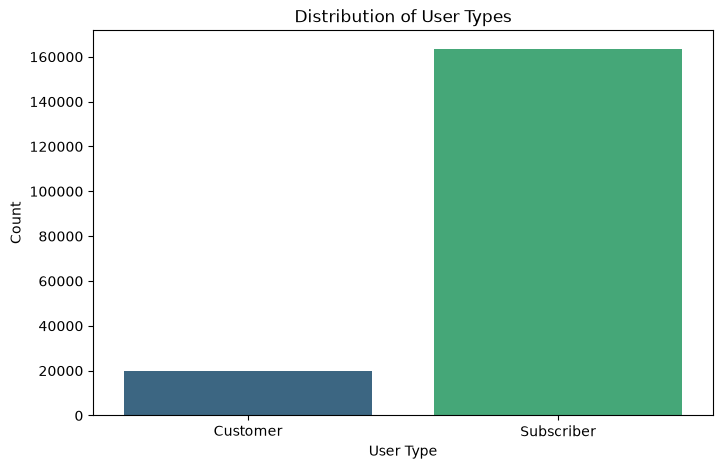

In [28]:
## I will import seaborn library to support me in making visualizations 

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
sns.countplot(data=data, x='user_type', palette='viridis')

plt.title('Distribution of User Types')
plt.xlabel('User Type')
plt.ylabel('Count')
plt.show()

> ### <mark>Your analsys and exploration here </mark>

The majority of users are Subscribers (over 160,000 trips), representing about 90% of total trips.

# <a id="2"> 2 ) What is the distribution for the bike share users on all Trips?</a>

C:\Users\Maydoum\AppData\Local\Temp\ipykernel_20328\3842877558.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x='bike_share_for_all_trip', palette='Set2')


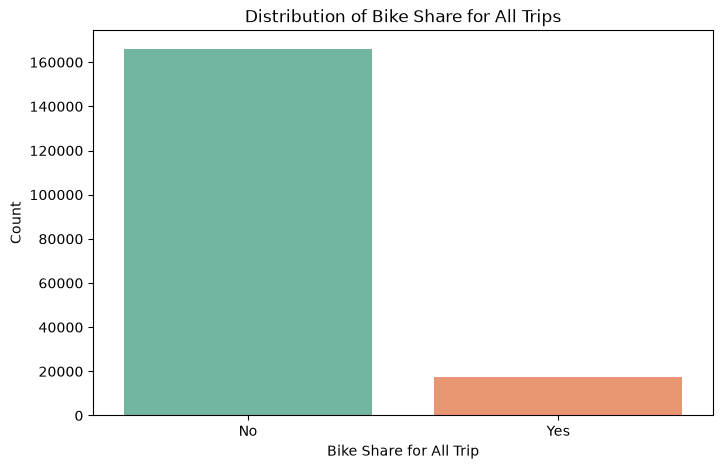

In [29]:
plt.figure(figsize=(8, 5))
sns.countplot(data=data, x='bike_share_for_all_trip', palette='Set2')

plt.title('Distribution of Bike Share for All Trips')
plt.xlabel('Bike Share for All Trip')
plt.ylabel('Count')
plt.show()

> ### <mark>Your analsys and exploration here </mark>

The vast majority of trips (over 160,000) **did not use** the "Bike Share for All" program (**No**).

# <a id="3"> 3 ) What is the distribution for users' ages? </a>

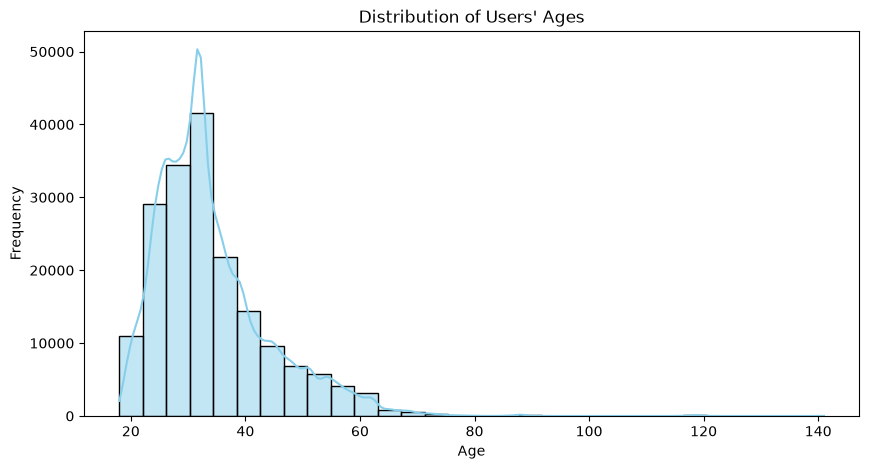

In [30]:
plt.figure(figsize=(10, 5))
sns.histplot(data=data, x='member_age', bins=30, kde=True, color='skyblue')

plt.title("Distribution of Users' Ages")
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

> ### <mark>Your analsys and exploration here </mark>

* The age distribution is **right-skewed**, with the majority of users concentrated between **25 and 35 years old**.

* The peak of usage occurs around **30–32 years**, showing that the core user base consists of young adults and working professionals.


# <a id="4">  4 ) . Do the users' ages have outlier values?</a>


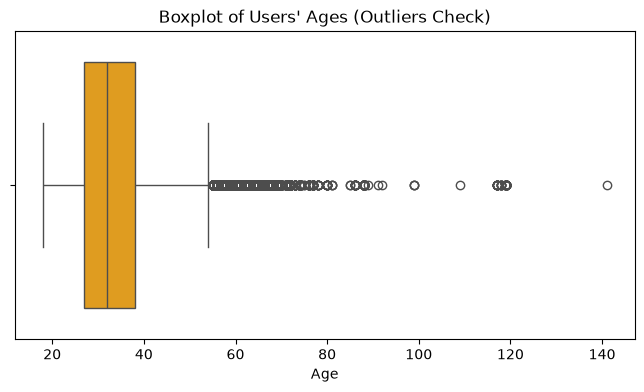

In [31]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=data, x='member_age', color='orange')

plt.title("Boxplot of Users' Ages (Outliers Check)")
plt.xlabel('Age')
plt.show()

> ### <mark>Your analsys and exploration here </mark>

the users' ages contain significant outlier values.

The interquartile range (IQR) shows that 50% of users are aged between roughly **27 and 38 years**, with a median age of around **32**.

# <a id="5">  5 ) . What is the distribution for the trip duration in minutes? </a>

In [32]:
## Review the statistic for trip duration in minutes
data['duration_min'].describe()

count    183416.000000
mean         12.101122
std          29.906197
min           1.016667
25%           5.416667
50%           8.566667
75%          13.266667
max        1424.066667
Name: duration_min, dtype: float64

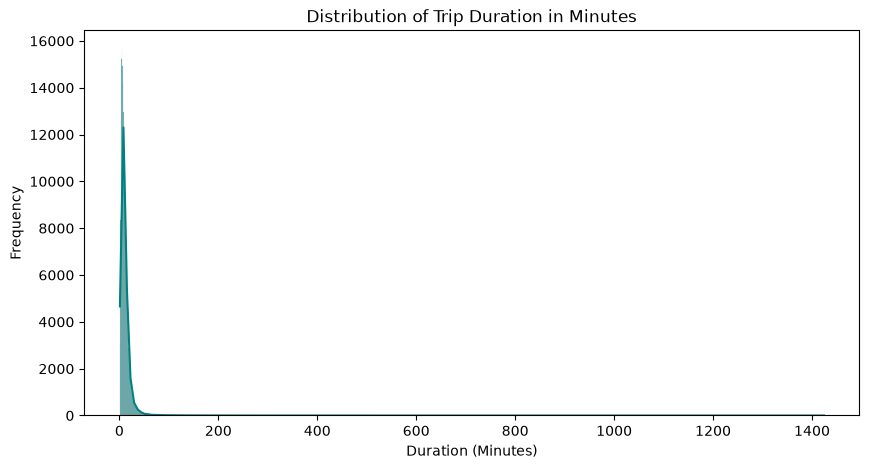

In [33]:
# Make visualization to easy get insight
plt.figure(figsize=(10, 5))
sns.histplot(data=data, x='duration_min', bins=60, binrange=(0, 60), kde=True, color='teal')

plt.title('Distribution of Trip Duration in Minutes')
plt.xlabel('Duration (Minutes)')
plt.ylabel('Frequency')
plt.show()

> ### <mark>Your analsys and exploration here </mark>

The distribution of trip duration in minutes is **strongly right-skewed**.

Most trips are short-duration rides, concentrated heavily between **5 and 15 minutes**, peaking around **8–10 minutes**.


# <a id="6"> 6 ) . What is the distribution for member_gender?</a>

C:\Users\Maydoum\AppData\Local\Temp\ipykernel_20328\3174322883.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x='member_gender', palette='muted')


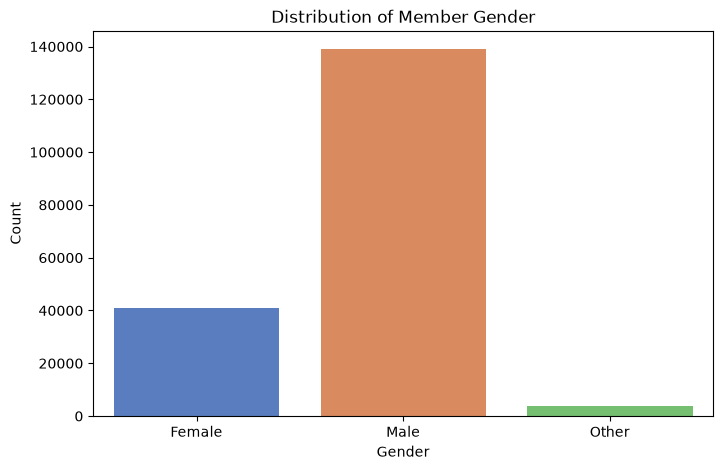

In [34]:
# Make visualization to easy get insight
plt.figure(figsize=(8, 5))
sns.countplot(data=data, x='member_gender', palette='muted')

plt.title('Distribution of Member Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

> ### <mark>Your analsys and exploration here </mark>

* **Male** users dominate the service, accounting for the vast majority of trips (over 130,000 rides / ~74%).

* **Female** users represent roughly 21% of total rides (around 40,000 trips).

* The **Other** gender category makes up a very small fraction (around 2%).

# <a id="7">    7 )  . What is the distribution for the trip duration in Hours?  </a>

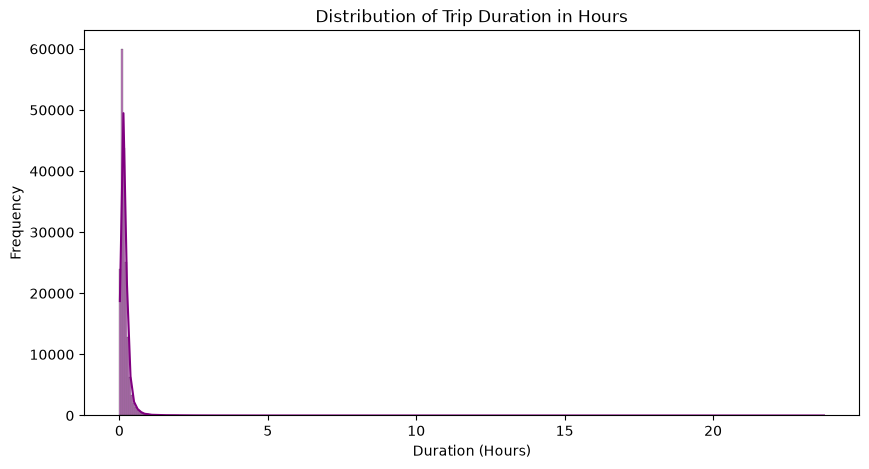

In [35]:
# Make visualization to easy get insight
plt.figure(figsize=(10, 5))
sns.histplot(data=data, x='duration_hours', bins=30, binrange=(0, 2), kde=True, color='purple')

plt.title('Distribution of Trip Duration in Hours')
plt.xlabel('Duration (Hours)')
plt.ylabel('Frequency')
plt.show()

> ### <mark>Your analsys and exploration here </mark>

* The distribution of trip duration in hours is **extremely right-skewed**.

* The vast majority of trips last **less than 0.5 hours** (30 minutes), with most rides completed in under 15–20 minutes.

* **Long Durations:** Only a negligible fraction of trips extend beyond 1 hour, reaching up to 24 hours in extreme cases (outliers).

### The variables distribution:


> The distribution of duration present that most of the trips were less than 30 minutes ( we can notice that from the minutes and the hour charts )


> And the Age distribution is ( left Skewed ) as most users age are  22 - 39


> Most users are subscribers, not Customers and  Males as shown in the charts above.



### Were there any interesting and outliers 


- We got Age outliers for for more than 100 .



- The distribution of duration was strange where the minutes and the hour charts were 30 minutes or less.

# <p style="border-radius:15px;border-style:solid;border-color:lightblue;border-width:3px;background-color:lightblue;padding: 20px;font-family:Verdana;color:#D81F26;font-size:30px;text-align: center;">Bivariate Exploration</p>
# <a id="111"> Bivariate Exploration</a>

Now let's investigate relationships between pairs of variables in our data.

# <a id="8"> 8) . What the average duration of trip for the categories of user type?</a>

In [36]:
# Distribution of Age by user types
data.groupby('user_type')['duration_min'].mean()


user_type
Customer      23.874417
Subscriber    10.670888
Name: duration_min, dtype: float64

# Make visualization to easy get insight


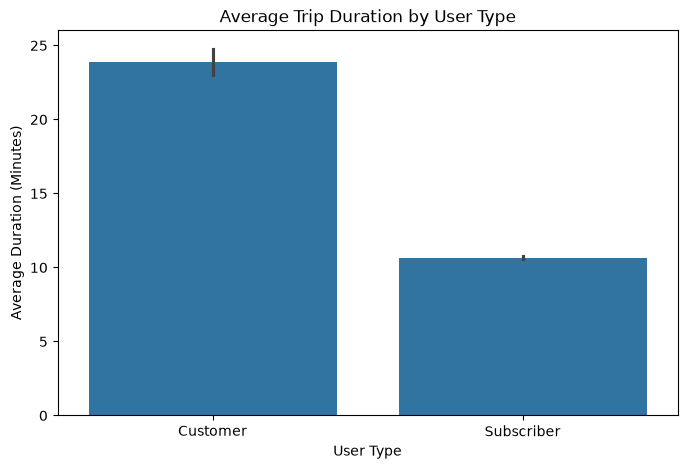

In [37]:
plt.figure(figsize=(8, 5))
sns.barplot(data=data, x='user_type', y='duration_min')

plt.title('Average Trip Duration by User Type')
plt.xlabel('User Type')
plt.ylabel('Average Duration (Minutes)')
plt.show()

> ### <mark>Your analsys and exploration here </mark>

* **Casual Customers** have a significantly higher average trip duration (~24 minutes) compared to **Subscribers** (~10–11 minutes).

* **Insight:** Even though Subscribers represent the majority of total trips, their rides are much shorter and consistent, suggesting routine commuting (e.g., work/school). Casual Customers likely use the bikes for leisure, tourism, or longer trips.

# <a id="9">    9 ) . How long is the duration of the trip for each gender in minutes?  </a>

C:\Users\Maydoum\AppData\Local\Temp\ipykernel_20328\819697972.py:6: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=data, x='member_gender', y='duration_min', palette='Set2', ci=None)
C:\Users\Maydoum\AppData\Local\Temp\ipykernel_20328\819697972.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data, x='member_gender', y='duration_min', palette='Set2', ci=None)


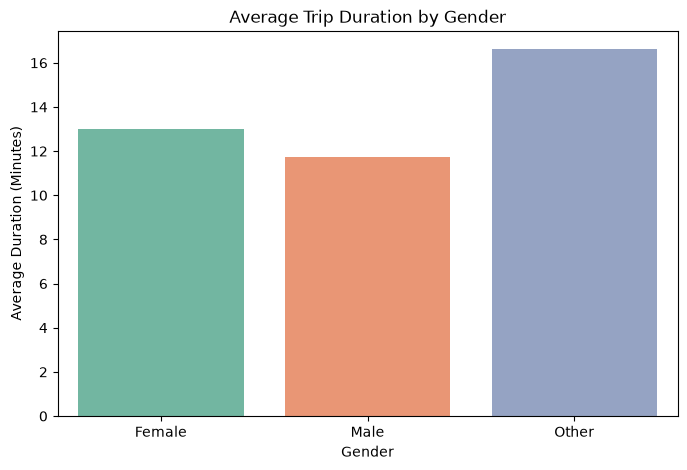

In [46]:
# Make visualization to easy get insight

# ------------------------Duration distribution by member gender

plt.figure(figsize=(8, 5))
sns.barplot(data=data, x='member_gender', y='duration_min', palette='Set2', ci=None)

plt.title('Average Trip Duration by Gender')
plt.xlabel('Gender')
plt.ylabel('Average Duration (Minutes)')
plt.show()

# Make visualization to easy get insight


> ### <mark>Your analsys and exploration here </mark>

* Users identifying as **Other** have the highest average trip duration (~16.5 minutes).

* **Female** users have a higher average trip duration (~13 minutes) compared to **Male** users (~11.7 minutes).

* **Insight:** Even though males constitute the majority of total riders, their average trip duration is shorter, likely indicating highly direct commute patterns. Females and 'Other' genders tend to take slightly longer trips.

# <a id="10 "> 10 ) . How long is the duration of the trip for each user_type in minutes?  </a>

C:\Users\Maydoum\AppData\Local\Temp\ipykernel_20328\13251228.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='user_type', y='duration_min', palette='Set2')


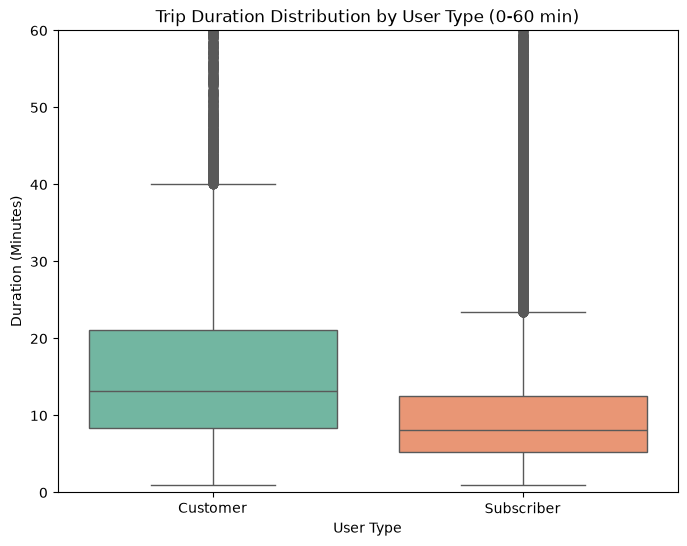

In [47]:

# Make visualization to easy get insight
plt.figure(figsize=(8, 6))
sns.boxplot(data=data, x='user_type', y='duration_min', palette='Set2')

plt.ylim(0, 60)

plt.title('Trip Duration Distribution by User Type (0-60 min)')
plt.xlabel('User Type')
plt.ylabel('Duration (Minutes)')
plt.show()

> ### <mark>Your analsys and exploration here </mark>
* **Customers** have a higher median trip duration (~13–14 minutes) and a wider Interquartile Range (IQR) spanning from 8 to 21 minutes, showing higher variance in ride times.

* **Subscribers** have a much lower median duration (~8 minutes) with a tight IQR (5 to 12 minutes), reflecting predictable and short trips.

* **Insight:** Subscriber ride durations are highly standardized around short commute windows, whereas casual Customers display a broader range of durations typical of casual or recreational behavior.

# <a id="11">  11 ) . How the user distribution depending on their Age and user_type ? </a>

C:\Users\Maydoum\AppData\Local\Temp\ipykernel_20328\3685626748.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='user_type', y='member_age', palette='Set2')


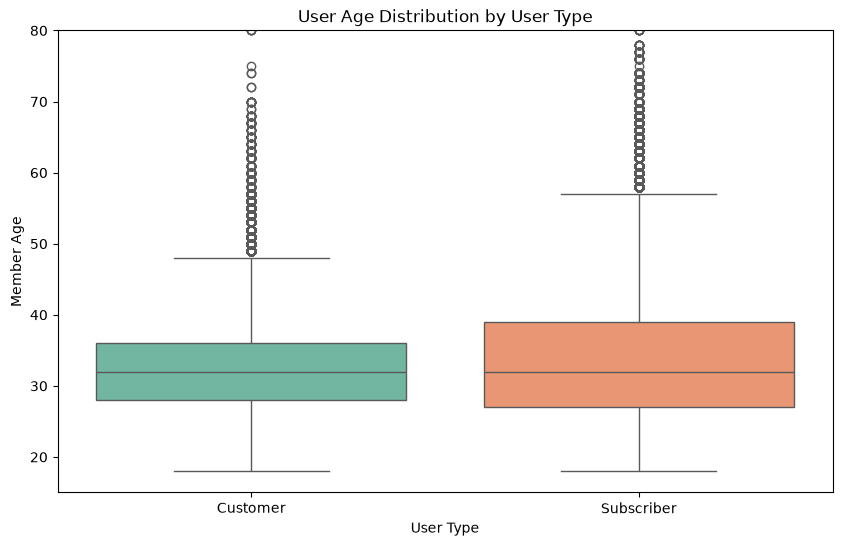

In [49]:

# Make visualization to easy get insight
plt.figure(figsize=(10, 6))
sns.boxplot(data=data, x='user_type', y='member_age', palette='Set2')

plt.ylim(15, 80)

plt.title('User Age Distribution by User Type')
plt.xlabel('User Type')
plt.ylabel('Member Age')
plt.show()

> ### <mark>Your analsys and exploration here </mark>
* Both **Customers** and **Subscribers** share a nearly identical median age of around **32 years**.

* **Subscribers** show a slightly wider Interquartile Range (IQR) spanning from ~27 to 39 years, whereas **Customers** cluster more tightly between ~28 and 36 years.

* **Older Demographics:** Subscribers feature a wider distribution of older age groups (extending past 55+), likely representing long-term commuters across various career stages.

#  <a id="12"> 12 ). How the user distribution depending on their Age and member_gender ?</a>

C:\Users\Maydoum\AppData\Local\Temp\ipykernel_20328\1959093403.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='member_gender', y='member_age', palette='Set2')


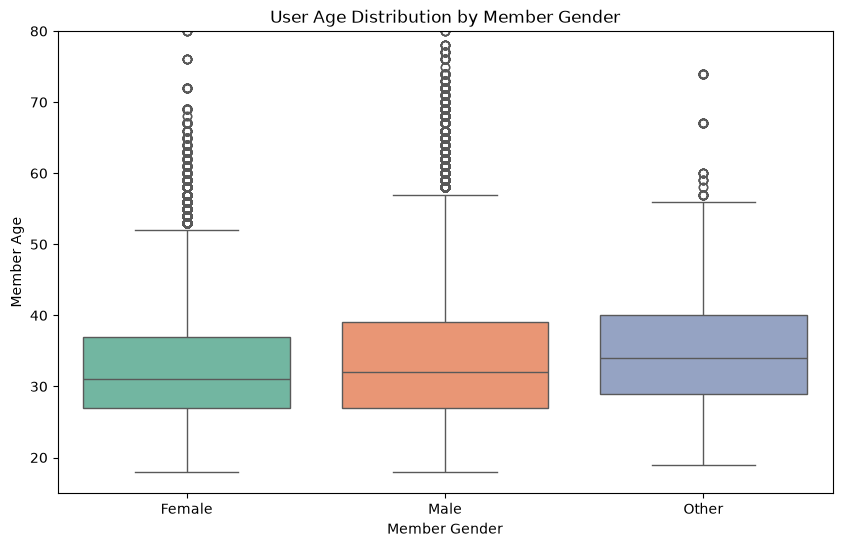

In [50]:
# Make visualization to easy get insight
plt.figure(figsize=(10, 6))
sns.boxplot(data=data, x='member_gender', y='member_age', palette='Set2')

plt.ylim(15, 80)

plt.title('User Age Distribution by Member Gender')
plt.xlabel('Member Gender')
plt.ylabel('Member Age')
plt.show()

> ### <mark>Your analsys and exploration here </mark>

* **Median Age:** Female and Male riders share a very similar median age (~31–32 years), while the **Other** category shows a slightly higher median (~34 years).

* **Age Spread:** Both Male and Female categories display consistent Interquartile Ranges (IQR) between ~27 and 39 years. The **Other** category has a broader spread extending up to 40 years.

* **Outliers:** Significant age outliers are present across all groups, particularly among Male and Female riders extending well past 55–60 years.

### Talk about some of the relationships you observed in this part of the investigation. How did the feature(s) of interest vary with other features in the dataset?

> ...................* **Trip Duration vs. User Type:** Casual Customers take significantly longer trips (~24 minutes average, median 13 minutes) compared to Subscribers (~10–11 minutes average, median 8 minutes), highlighting a clear functional divide between recreational riders and daily commuters.

* **Trip Duration vs. Gender:** Female riders (~13 min) and 'Other' gender categories (~16.5 min) tend to have longer average trip durations than Male riders (~11.7 min).


### Did you observe any interesting relationships between the other features (not the main feature(s) of interest)?

> .................... * **Age vs. User Type & Gender:** The median age is remarkably consistent across user types and genders (~31–34 years). However, Subscribers and Male riders exhibit a much wider spread of older users (extending past 55+ years), indicating higher adoption among mature working professionals compared to casual riders.

# <p style="border-radius:15px;border-style:solid;border-color:lightblue;border-width:3px;background-color:lightblue;padding: 20px;font-family:Verdana;color:#D81F26;font-size:30px;text-align: center;">Multivariate Exploration</p>
# <a id="1111"> Multivariate Exploration </a>

> Create plots of three or more variables to investigate your data even
further. Make sure that your investigations are justified, and follow from
your work in the previous sections.

C:\Users\Maydoum\AppData\Local\Temp\ipykernel_20328\2883703607.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=data, x='user_type', y='duration_min', hue='member_gender', palette='Set2', ci=None)


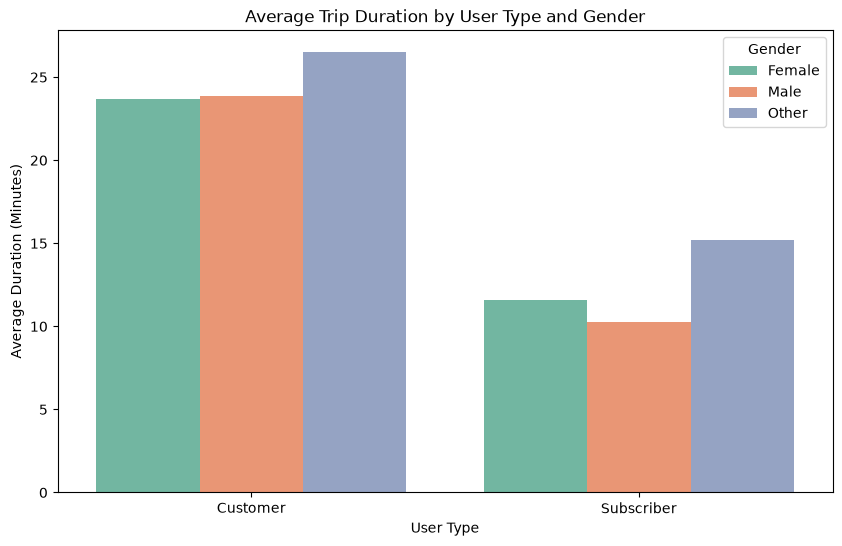

In [51]:
## check your work 
plt.figure(figsize=(10, 6))
sns.barplot(data=data, x='user_type', y='duration_min', hue='member_gender', palette='Set2', ci=None)

plt.title('Average Trip Duration by User Type and Gender')
plt.xlabel('User Type')
plt.ylabel('Average Duration (Minutes)')
plt.legend(title='Gender')
plt.show()


# <a id="13">  13 ) . What is the  Correlation between each variable in the dataset?</a>

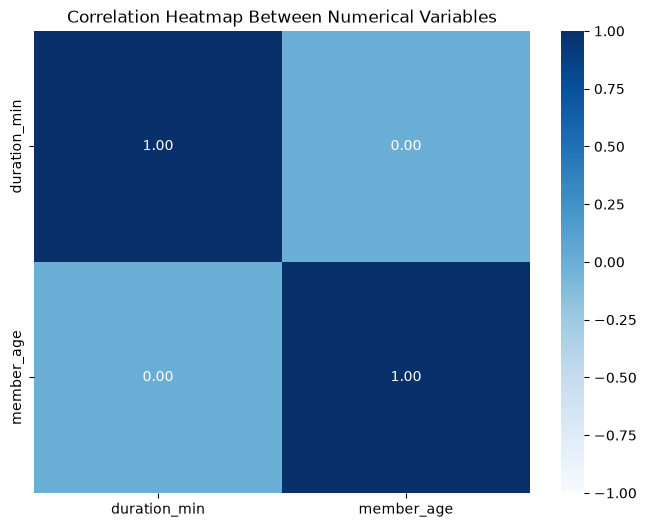

In [52]:
# Make visualization to easy get insight
plt.figure(figsize=(8, 6))
numeric_vars = ['duration_min', 'member_age']
sns.heatmap(data[numeric_vars].corr(), annot=True, fmt='.2f', cmap='Blues', vmin=-1, vmax=1)

plt.title('Correlation Heatmap Between Numerical Variables')
plt.show()



> ### <mark>Your analsys and exploration here </mark>
* **Correlation Value:** The Pearson correlation coefficient between `member_age` and `duration_min` is **0.00**.

* **Insight:** There is **no linear correlation** between user age and trip duration. A rider's age does not determine or predict how long their trip will last.

Example usage
- There is `no Correlation` for any variable with time ( `duration sec /minutes/hours`)



# <a id="14"> 14 )  .  What is the  Correlation between `specific numeric variables` in the dataset?</a>


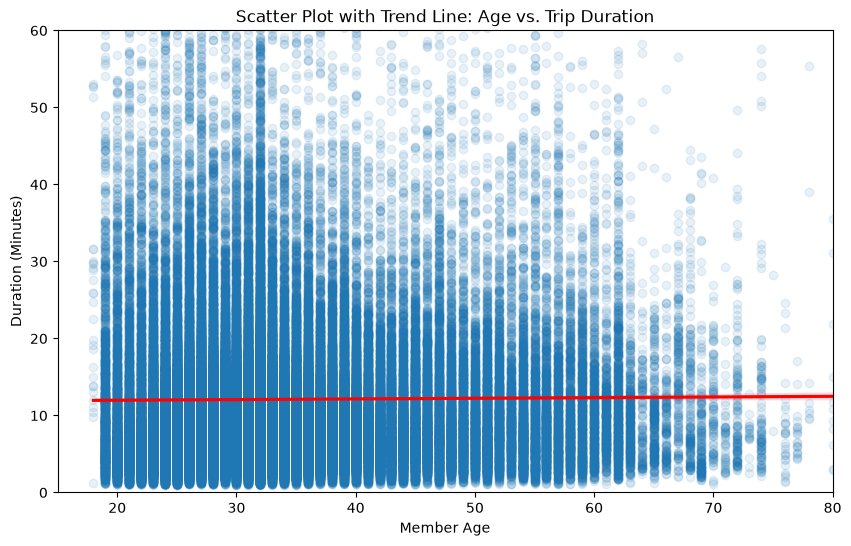

In [53]:
# Make visualization to easy get insight
plt.figure(figsize=(10, 6))
sns.regplot(data=data, x='member_age', y='duration_min', 
            scatter_kws={'alpha': 0.1}, line_kws={'color': 'red'})

plt.ylim(0, 60)
plt.xlim(15, 80)

plt.title('Scatter Plot with Trend Line: Age vs. Trip Duration')
plt.xlabel('Member Age')
plt.ylabel('Duration (Minutes)')
plt.show()



> ### <mark>Your analsys and exploration here </mark>

Example usage
- There is `no Correlation` for any variable with time ( `duration sec /minutes`)

* **Horizontal Trend Line:** The regression line is completely flat (slope near zero) across all age groups at ~12 minutes.

* **Density Concentration:** Data points are heavily concentrated among riders aged **25 to 45** taking trips under 20 minutes, with density tapering off for older age groups without altering the average duration.

* **Insight:** Age does not have a linear relationship with trip duration; users of all ages typically take short trips of similar average length.




- 




- 




# <a id="15">  15 ) What is the  Correlation between data_stat variables in the dataset?</a>


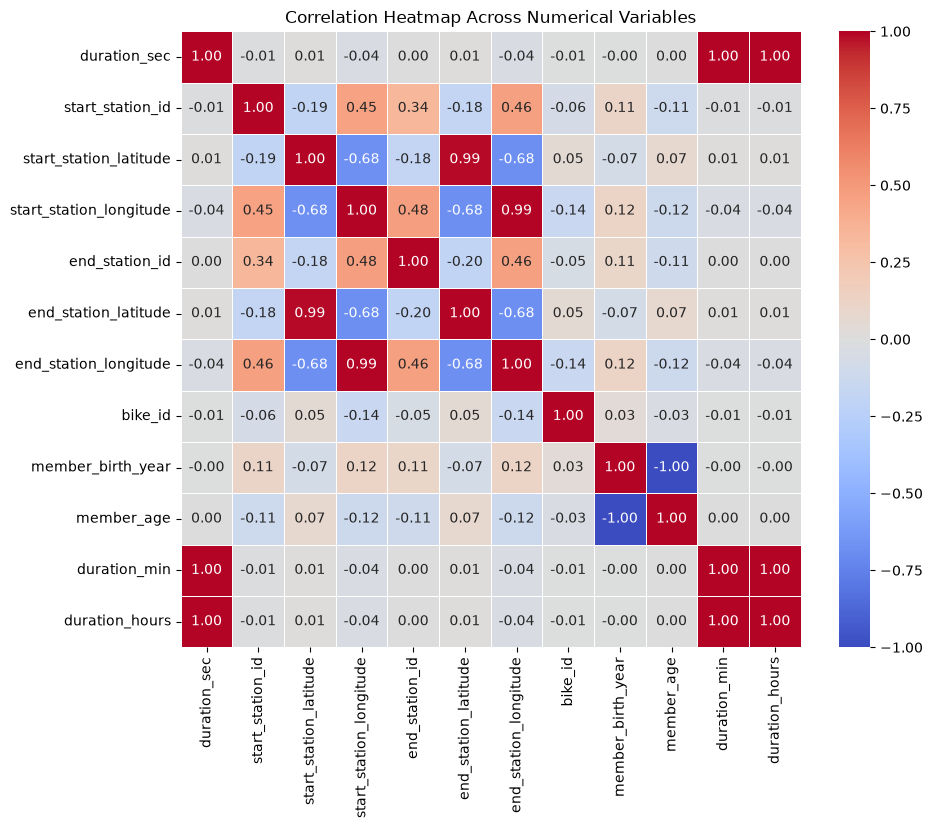

In [54]:

"""""This time I will use heatmap  to explain how Correlation between data_stat variables

in the dataset in more clear and specific percentage"""

# Make visualization to easy get insight

plt.figure(figsize=(10, 8))

numeric_cols = data.select_dtypes(include=['int64', 'float64']).columns

sns.heatmap(data[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)

plt.title('Correlation Heatmap Across Numerical Variables')
plt.show()

> ### <mark>The above charts show how Correlation between specific numeric variables in the dataset using heatmap plots  </mark>



**Actually the `heat map`  display the above ideas in clear percentages**



- There is `no Correlation` for any variable with time ( `duration sec /minutes`)




- There is a `negative  Correlation` between  member_birth_year  and age which normal.




- There is `no significant Correlation` for any variable with `bike_id `



# <p style="border-radius:15px;border-style:solid;border-color:lightblue;border-width:3px;background-color:lightblue;padding: 20px;font-family:Verdana;color:#D81F26;font-size:30px;text-align: center;">Conclusions</p>
# <a id="1100"> Conclusions </a>

#example
- ### Conclusions

* **User Type Behavior:** Casual Customers take longer trips (~24 minutes on average, median 13 minutes) compared to Subscribers (~10–11 minutes, median 8 minutes), indicating that Customers use bikes for recreational purposes while Subscribers use them for routine commutes.

* **Gender Breakdown:** The majority of users are Male; however, Female and 'Other' gender categories record longer average trip durations than Male users.

* **Age Distribution:** The user base is heavily concentrated between ages 25 and 45. There is no linear correlation ($r=0.00$) between user age and trip duration.

* **Combined Insights:** Trip duration is primarily influenced by the user type (Customer vs. Subscriber) rather than rider demographic variables like age.

---
## limitation 
example
- We got missing data which we fix some of them .

* **Missing Data:** Several rows had missing values in critical columns like `member_birth_year` and `member_gender`, which required cleaning/filtering during preprocessing.

* **Timeframe Constraints:** The dataset captures trip logs over a specific time window, which may introduce seasonal bias and limit long-term trend analysis.

* **Lack of Geospatial Metrics:** Exact trip distances (in kilometers) could not be precisely computed without full GPS coordinates, relying instead on duration as the primary proxy for usage.
- 
